# ATLAS - Stage 1: Data Validation

Goal: Validate Salmon 'quant.sf' files and the Ensembl transcript to gene mapping

Data Set Samples
BT-474_Trastuzumab_Resistance_1https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSM9067963   
BT-474_Trastuzumab_Resistance_2https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSM9067964 
BT-474_Trastuzumab_Resistance_3https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSM9067965 
BT-474_Trastuzumab_Sensible_1https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSM9067960 
BT-474_Trastuzumab_Sensible_2https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSM9067961 
BT-474_Trastuzumab_Sensible_3https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSM9067962

Human genes (GRCh38.p14) Biomart
FormatGene stable ID Transcript stable ID Gene namehttps://asia.ensembl.org/biomart/martview/6a137e8337a28bc1b13dbefe5c6ba809


Validation checks

1. Confirm all expected input files exist.
2. Inspect the structure of the Salmon quantification files.
3. Inspect the `tx2gene` mapping.
4. Check transcript-ID compatibility.
5. Measure the percentage of Salmon transcripts that have a mapping.
6. Confirm that each transcript maps to a gene.


1. Import Paths and Libraries
- should show the project root and data directory

In [4]:
from pathlib import Path

import pandas as pd

PROJECT_ROOT = Path.cwd().parent

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results"

print("Project root:", PROJECT_ROOT)
print("Raw data:", RAW_DIR)

Project root: /home/regulus/Documents/ATLAS
Raw data: /home/regulus/Documents/ATLAS/data/raw


2. Checking of Existing Data Files

In [5]:
expected_files = [
    "GSM9067960_TS1_quant.sf.gz",
    "GSM9067961_TS2_quant.sf.gz",
    "GSM9067962_TS3_quant.sf.gz",
    "GSM9067963_TR1_quant.sf.gz",
    "GSM9067964_TR2_quant.sf.gz",
    "GSM9067965_TR3_quant.sf.gz",
    "tx2gene.tsv",
]

for filename in expected_files:
    path = RAW_DIR / filename
    status = "OK" if path.exists() else "MISSING"
    print(f"{status:7} {filename}")

OK      GSM9067960_TS1_quant.sf.gz
OK      GSM9067961_TS2_quant.sf.gz
OK      GSM9067962_TS3_quant.sf.gz
OK      GSM9067963_TR1_quant.sf.gz
OK      GSM9067964_TR2_quant.sf.gz
OK      GSM9067965_TR3_quant.sf.gz
OK      tx2gene.tsv


3. Defining Samples into Resistant or Sensitive

In [6]:
samples = {
    "TS1": RAW_DIR / "GSM9067960_TS1_quant.sf.gz",
    "TS2": RAW_DIR / "GSM9067961_TS2_quant.sf.gz",
    "TS3": RAW_DIR / "GSM9067962_TS3_quant.sf.gz",
    "TR1": RAW_DIR / "GSM9067963_TR1_quant.sf.gz",
    "TR2": RAW_DIR / "GSM9067964_TR2_quant.sf.gz",
    "TR3": RAW_DIR / "GSM9067965_TR3_quant.sf.gz",
}

metadata = pd.DataFrame({
    "sample": list(samples.keys()),
    "condition": [
        "Sensitive",
        "Sensitive",
        "Sensitive",
        "Resistant",
        "Resistant",
        "Resistant",
    ],
})

metadata

,sample,condition
0,TS1,Sensitive
1,TS2,Sensitive
2,TS3,Sensitive
3,TR1,Resistant
4,TR2,Resistant
5,TR3,Resistant


4. Inspect One Salmon File Data to Match our Needed Data Columns
- The columns should be 
| Name  |  Length  | EffectiveLength   |  TPM   |  NumReads |

In [8]:
example_sample = "TS1"

quant_example = pd.read_csv(
    samples[example_sample],
    sep="\t",
    compression="gzip"
)

quant_example.head()

print("Rows:", len(quant_example))
print("Columns:", list(quant_example.columns))
print("\nFirst transcript IDs:")
print(quant_example["Name"].head(10).tolist())

Rows: 252045
Columns: ['Name', 'Length', 'EffectiveLength', 'TPM', 'NumReads']

First transcript IDs:
['ENST00000456328.2', 'ENST00000450305.2', 'ENST00000488147.1', 'ENST00000619216.1', 'ENST00000473358.1', 'ENST00000469289.1', 'ENST00000607096.1', 'ENST00000417324.1', 'ENST00000461467.1', 'ENST00000606857.1']


5. Inspect tx2gene.tsv (human gene transcript (GRCh38.p14))
* Columns should be | Gene Stable ID | Transcript Stable ID | Gene Name |

In [10]:
tx2gene = pd.read_csv(
    RAW_DIR / "tx2gene.tsv",
    sep="\t"
)

tx2gene.head()

print("Rows:", len(tx2gene))
print("Columns:", list(tx2gene.columns))

Rows: 670670
Columns: ['Gene stable ID', 'Transcript stable ID', 'Gene name']


6. Normalization of transcipt IDs
- GEO Data set IDs should match the BioMart IDs

In [11]:
def strip_version(ids):
    return ids.astype(str).str.split(".").str[0]

quant_transcripts = strip_version(quant_example["Name"])
mapping_transcripts = strip_version(tx2gene["Transcript stable ID"])

print("Example Salmon transcripts:", quant_transcripts.head().tolist())
print("Example mapping transcripts:", mapping_transcripts.head().tolist())

Example Salmon transcripts: ['ENST00000456328', 'ENST00000450305', 'ENST00000488147', 'ENST00000619216', 'ENST00000473358']
Example mapping transcripts: ['ENST00000387314', 'ENST00000389680', 'ENST00000387342', 'ENST00000387347', 'ENST00000386347']


7. Validation of Actual Matching Rate
Why do we need to validate?
- the quant.sf files are transcript level data while tx2gene.tsv is a human gene data which will be the bridge to doing the DEG analysis to eventually match the medicine in the CMAP

In [12]:
mapping_set = set(mapping_transcripts)

matched = quant_transcripts.isin(mapping_set)

print(f"Total Salmon transcripts: {len(quant_transcripts):,}")
print(f"Matched transcripts:      {matched.sum():,}")
print(f"Unmatched transcripts:    {(~matched).sum():,}")
print(f"Match rate:               {matched.mean() * 100:.2f}%")

Total Salmon transcripts: 252,045
Matched transcripts:      250,857
Unmatched transcripts:    1,188
Match rate:               99.53%


Trial 1:
Total Salmon transcripts: 252,045
Matched transcripts:      250,857
Unmatched transcripts:    1,188
Match rate:               99.53%

8. Checking of all Samples

In [13]:
validation_results = []

for sample, path in samples.items():
    quant = pd.read_csv(
        path,
        sep="\t",
        compression="gzip",
        usecols=["Name"]
    )

    transcripts = strip_version(quant["Name"])
    matched = transcripts.isin(mapping_set)

    validation_results.append({
        "sample": sample,
        "total_transcripts": len(transcripts),
        "matched": matched.sum(),
        "unmatched": (~matched).sum(),
        "match_rate_percent": matched.mean() * 100,
    })

validation_df = pd.DataFrame(validation_results)

validation_df

,sample,total_transcripts,matched,unmatched,match_rate_percent
0,TS1,252045,250857,1188,99.528656
1,TS2,252045,250857,1188,99.528656
2,TS3,252045,250857,1188,99.528656
3,TR1,252045,250857,1188,99.528656
4,TR2,252045,250857,1188,99.528656
5,TR3,252045,250857,1188,99.528656


Gene Count Construction

Convert transcript-level Salmon quantification into a gene-level count matrix using the Ensembl transcript to gene mapping.

In [14]:
tx2gene = pd.read_csv(
    RAW_DIR / "tx2gene.tsv",
    sep="\t"
)

tx2gene.head()

,Gene stable ID,Transcript stable ID,Gene name
0,ENSG00000210049,ENST00000387314,MT-TF
1,ENSG00000211459,ENST00000389680,MT-RNR1
2,ENSG00000210077,ENST00000387342,MT-TV
3,ENSG00000210082,ENST00000387347,MT-RNR2
4,ENSG00000209082,ENST00000386347,MT-TL1


In [15]:
print(tx2gene.columns.tolist())

['Gene stable ID', 'Transcript stable ID', 'Gene name']


In [16]:
quant = pd.read_csv(
    samples["TS1"],
    sep="\t",
    compression="gzip"
)

quant.head()

,Name,Length,EffectiveLength,TPM,NumReads
0,ENST00000456328.2,1657,1462.000,0.000000,0.000
1,ENST00000450305.2,632,438.000,0.000000,0.000
2,ENST00000488147.1,1351,1286.407,2.170065,74.214
3,ENST00000619216.1,68,6.000,0.000000,0.000
4,ENST00000473358.1,712,517.000,0.000000,0.000


Mapping

In [17]:
tx2gene_clean = tx2gene[
    ["Gene stable ID", "Transcript stable ID"]
].copy()

tx2gene_clean["Transcript stable ID"] = (
    tx2gene_clean["Transcript stable ID"]
    .astype(str)
    .str.split(".")
    .str[0]
)

tx2gene_clean.head()

,Gene stable ID,Transcript stable ID
0,ENSG00000210049,ENST00000387314
1,ENSG00000211459,ENST00000389680
2,ENSG00000210077,ENST00000387342
3,ENSG00000210082,ENST00000387347
4,ENSG00000209082,ENST00000386347


Processing of One Salmon File

In [19]:
def load_gene_counts(sample_name, filepath, tx2gene_mapping):
    quant = pd.read_csv(
        filepath,
        sep="\t",
        compression="gzip",
        usecols=["Name", "NumReads"]
    )

    # Remove transcript version suffix
    quant["transcript_id"] = (
        quant["Name"]
        .astype(str)
        .str.split(".")
        .str[0]
    )

    # Map transcript → gene
    quant = quant.merge(
        tx2gene_mapping,
        left_on="transcript_id",
        right_on="Transcript stable ID",
        how="left"
    )

    # Report unmapped transcripts
    unmapped = quant["Gene stable ID"].isna().sum()
    total = len(quant)

    print(
        f"{sample_name}: "
        f"{total - unmapped:,}/{total:,} transcripts mapped "
        f"({(total - unmapped) / total * 100:.2f}%)"
    )

    # Keep mapped transcripts only
    quant = quant.dropna(subset=["Gene stable ID"])

    # Aggregate transcript counts to gene counts
    gene_counts = (
        quant.groupby("Gene stable ID")["NumReads"]
        .sum()
        .rename(sample_name)
    )

    return gene_counts

quant.sf
   ↓
remove .1 / .2 from ENST IDs
   ↓
ENST → ENSG using tx2gene
   ↓
group transcripts belonging to the same gene
   ↓
sum NumReads
   ↓
gene-level counts

Processing of all samples

In [20]:
gene_count_series = []

for sample_name, filepath in samples.items():
    counts = load_gene_counts(
        sample_name,
        filepath,
        tx2gene_clean
    )
    gene_count_series.append(counts)

gene_counts = pd.concat(
    gene_count_series,
    axis=1
).fillna(0)

gene_counts.head()

TS1: 250,857/252,045 transcripts mapped (99.53%)
TS2: 250,857/252,045 transcripts mapped (99.53%)
TS3: 250,857/252,045 transcripts mapped (99.53%)
TR1: 250,857/252,045 transcripts mapped (99.53%)
TR2: 250,857/252,045 transcripts mapped (99.53%)
TR3: 250,857/252,045 transcripts mapped (99.53%)


,TS1,TS2,TS3,TR1,TR2,TR3
Gene stable ID,,,,,,
ENSG00000000003,144.564,185.000,170.136,512.879,299.357,400.329
ENSG00000000005,0.000,0.000,0.000,0.000,0.000,0.000
ENSG00000000419,748.002,583.000,960.031,983.857,890.174,866.176
ENSG00000000457,542.000,487.999,564.120,1096.000,676.032,883.000
ENSG00000000460,575.070,661.033,709.637,1255.626,869.156,1074.011


Saving of matrix in Processed Data Folder
ATLAS/
└── data/
    └── processed/
        └── gene_counts.csv

In [21]:
print("Genes:", gene_counts.shape[0])
print("Samples:", gene_counts.shape[1])
print("\nMissing values:")
print(gene_counts.isna().sum().sum())

print("\nTotal counts per sample:")
print(gene_counts.sum())

Genes: 61490
Samples: 6

Missing values:
0

Total counts per sample:
TS1    2.403930e+07
TS2    2.617537e+07
TS3    2.693960e+07
TR1    2.701112e+07
TR2    2.229359e+07
TR3    2.146150e+07
dtype: float64


In [22]:
gene_counts.describe()

,TS1,TS2,TS3,TR1,TR2,TR3
count,6.149000e+04,6.149000e+04,6.149000e+04,61490.000000,61490.000000,61490.000000
mean,3.909465e+02,4.256850e+02,4.381135e+02,439.276607,362.556318,349.024258
std,7.754086e+03,8.256948e+03,8.245001e+03,5503.273931,4652.519165,4465.326723
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000
25%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000
50%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000
75%,5.000000e+00,4.205750e+00,5.000000e+00,5.000000,5.000000,4.029000
max,1.054198e+06,1.136073e+06,1.135320e+06,678989.655000,589963.082000,568400.484000


Current Results. 
Check	        Result	        Interpretation
Genes	        61,490	        Reasonable number of Ensembl genes represented
Samples	        6	            Correct: TS1–TS3 + TR1–TR3
Missing values	0	            ✅ Good
Total counts	~21–27 million/sample	Reasonable magnitude
Median	0	Expected for a whole-gene matrix; many genes aren't expressed
75th percentile	~4–5	Lots of low-count genes
Maximum	~568k–1.14M	Highly expressed genes exist

Count Matrix Quality Check

In [23]:
library_sizes = gene_counts.sum().sort_values(ascending=False)

print("Total estimated counts per sample:")
print(library_sizes)

Total estimated counts per sample:
TR1    2.701112e+07
TS3    2.693960e+07
TS2    2.617537e+07
TS1    2.403930e+07
TR2    2.229359e+07
TR3    2.146150e+07
dtype: float64


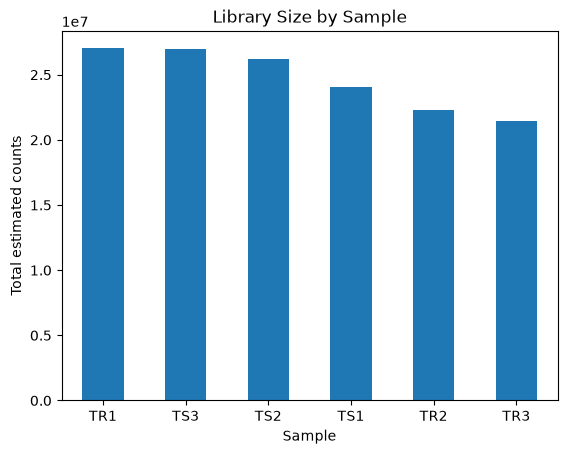

In [24]:
import matplotlib.pyplot as plt

library_sizes.plot(kind="bar")

plt.ylabel("Total estimated counts")
plt.xlabel("Sample")
plt.title("Library Size by Sample")
plt.xticks(rotation=0)
plt.show()

Transcript-to-Gene Mapping Uniqueness

Verify that each transcript maps to exactly one gene before using the mapping for count aggregation.

In [25]:
# How many unique transcript IDs are in the mapping?
unique_transcripts = tx2gene_clean["Transcript stable ID"].nunique()

# How many total rows are in the mapping?
total_mapping_rows = len(tx2gene_clean)

print(f"Total mapping rows:      {total_mapping_rows:,}")
print(f"Unique transcript IDs:   {unique_transcripts:,}")
print(f"Duplicate transcript rows: {total_mapping_rows - unique_transcripts:,}")

Total mapping rows:      670,670
Unique transcript IDs:   670,670
Duplicate transcript rows: 0


In [26]:
transcript_gene_counts = (
    tx2gene_clean
    .groupby("Transcript stable ID")["Gene stable ID"]
    .nunique()
)

multi_gene_transcripts = transcript_gene_counts[
    transcript_gene_counts > 1
]

print(
    "Transcripts mapping to multiple genes:",
    len(multi_gene_transcripts)
)

Transcripts mapping to multiple genes: 0


Best Case Scenario
- Transcriptt mapping to multiple genes: 0

| Check                         |       Result | Status |
| ----------------------------- | -----------: | :----: |
| 6 Salmon files found          |          6/6 |    ✅   |
| Salmon structure              |      Correct |    ✅   |
| Ensembl mapping               | 670,670 rows |    ✅   |
| Transcript matching           |       99.53% |    ✅   |
| Duplicate transcript mappings |            0 |    ✅   |
| Transcript → multiple genes   |            0 |    ✅   |
| Gene matrix                   |   61,490 × 6 |    ✅   |
| Missing gene counts           |            0 |    ✅   |
| Library sizes                 | 21.46–27.01M |    ✅   |


Sample-Level Quality Control

Assess similarity between samples using gene-expression correlations.

Biological replicates within the same condition should generally show higher similarity than unrelated samples.

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# Log-transform the counts to reduce the influence of highly expressed genes
log_counts = np.log2(gene_counts + 1)

# Calculate Pearson correlation between samples
correlation = log_counts.corr()

correlation

,TS1,TS2,TS3,TR1,TR2,TR3
TS1,1.000000,0.990795,0.991081,0.979405,0.979285,0.979217
TS2,0.990795,1.000000,0.990239,0.978236,0.977672,0.977781
TS3,0.991081,0.990239,1.000000,0.980358,0.980082,0.980018
TR1,0.979405,0.978236,0.980358,1.000000,0.990150,0.992374
TR2,0.979285,0.977672,0.980082,0.990150,1.000000,0.990247
TR3,0.979217,0.977781,0.980018,0.992374,0.990247,1.000000


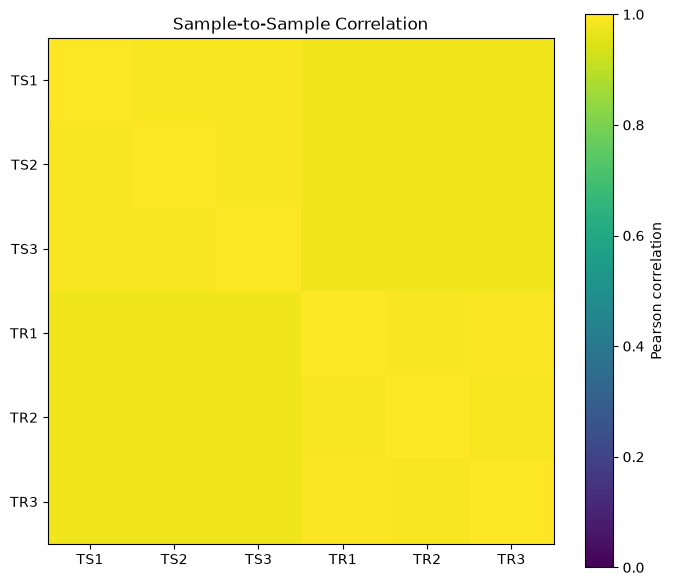

In [28]:
fig, ax = plt.subplots(figsize=(7, 6))

im = ax.imshow(correlation, vmin=0, vmax=1)

ax.set_xticks(range(len(correlation.columns)))
ax.set_yticks(range(len(correlation.index)))

ax.set_xticklabels(correlation.columns)
ax.set_yticklabels(correlation.index)

plt.colorbar(im, ax=ax, label="Pearson correlation")

ax.set_title("Sample-to-Sample Correlation")
plt.tight_layout()
plt.show()

## Sample Correlation QC — Result
*"Sample correlation QC means checking how similar the gene-expression patterns are between your samples."*

All six samples show high pairwise Pearson correlations.

Sensitive biological replicates (TS1–TS3) show correlations of approximately 0.990–0.991.

Resistant biological replicates (TR1–TR3) show correlations of approximately 0.990–0.992.

Correlations between Sensitive and Resistant samples are slightly lower, approximately 0.978–0.980.

Overall, the samples show strong within-condition consistency with no obvious correlation-based outlier.

| Check | Result | Status |
|---|---:|:---:|
| 6 Salmon files found | 6/6 | ✅ |
| Salmon structure | Correct | ✅ |
| Ensembl mapping | 670,670 rows | ✅ |
| Transcript matching | 99.53% | ✅ |
| Duplicate transcript mappings | 0 | ✅ |
| Transcript → multiple genes | 0 | ✅ |
| Gene matrix | 61,490 × 6 | ✅ |
| Missing gene counts | 0 | ✅ |
| Library sizes | 21.46–27.01M | ✅ |
| Mapping uniqueness | No duplicates / multi-gene mappings | ✅ |
| Sample correlations | 0.978–0.992 | ✅ |
| Correlation-based outliers | None obvious | ✅ |

Principal Component Analysis (PCA)

PCA is used to visualize overall similarities and differences between samples.

Samples with similar gene-expression patterns should appear closer together in the PCA plot.

In [29]:
log_counts = np.log2(gene_counts + 1)

log_counts.head()

,TS1,TS2,TS3,TR1,TR2,TR3
Gene stable ID,,,,,,
ENSG00000000003,7.185510,7.539159,7.418999,9.005285,8.230534,8.648642
ENSG00000000005,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000000419,9.548826,9.189825,9.908439,9.943770,9.799563,9.760181
ENSG00000000457,9.084808,8.933688,9.142413,10.099348,9.403080,9.787903
ENSG00000000460,9.170100,9.370759,9.472969,10.295340,9.765130,10.070136


In [30]:
from sklearn.decomposition import PCA

# Transpose so:
# rows = samples
# columns = genes
X = log_counts.T

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X)

print("PC1 explained variance:", pca.explained_variance_ratio_[0])
print("PC2 explained variance:", pca.explained_variance_ratio_[1])
print(
    "Total explained variance:",
    pca.explained_variance_ratio_[:2].sum()
)

PC1 explained variance: 0.5475754079958189
PC2 explained variance: 0.13074376979934596
Total explained variance: 0.6783191777951649


In [31]:
pca_df = pd.DataFrame(
    pca_result,
    columns=["PC1", "PC2"],
    index=gene_counts.columns
)

pca_df

,PC1,PC2
TS1,-80.200392,9.284117
TS2,-87.695900,-2.242953
TS3,-70.420750,-12.320806
TR1,86.793502,-51.570669
TR2,74.185563,76.270882
TR3,77.337976,-19.420572


In [32]:
pca_df["Condition"] = [
    "Sensitive",
    "Sensitive",
    "Sensitive",
    "Resistant",
    "Resistant",
    "Resistant"
]

pca_df

,PC1,PC2,Condition
TS1,-80.200392,9.284117,Sensitive
TS2,-87.695900,-2.242953,Sensitive
TS3,-70.420750,-12.320806,Sensitive
TR1,86.793502,-51.570669,Resistant
TR2,74.185563,76.270882,Resistant
TR3,77.337976,-19.420572,Resistant


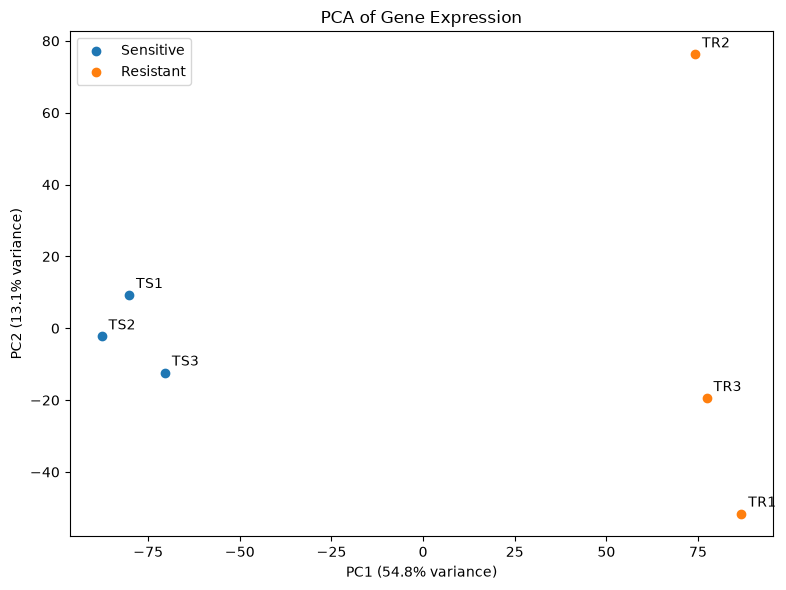

In [33]:
fig, ax = plt.subplots(figsize=(8, 6))

for condition in ["Sensitive", "Resistant"]:
    subset = pca_df[pca_df["Condition"] == condition]

    ax.scatter(
        subset["PC1"],
        subset["PC2"],
        label=condition
    )

    for sample, row in subset.iterrows():
        ax.annotate(
            sample,
            (row["PC1"], row["PC2"]),
            xytext=(5, 5),
            textcoords="offset points"
        )

pc1 = pca.explained_variance_ratio_[0] * 100
pc2 = pca.explained_variance_ratio_[1] * 100

ax.set_xlabel(f"PC1 ({pc1:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pc2:.1f}% variance)")
ax.set_title("PCA of Gene Expression")
ax.legend()

plt.tight_layout()
plt.show()

## PCA QC Conclusion

PCA was performed on log2-transformed gene-level counts.

PC1 explained 54.76% of the total variance, while PC2 explained
13.07%. Together, PC1 and PC2 explained 67.83% of the variance.

The three Sensitive samples (TS1, TS2, TS3) clustered on the
negative side of PC1, while the three Resistant samples
(TR1, TR2, TR3) clustered on the positive side of PC1.

This clear separation indicates that the Sensitive/Resistant
condition is a major source of variation in the dataset.

TR2 showed greater separation from TR1 and TR3 along PC2.
However, TR2 remained within the Resistant group along PC1 and
showed high sample-to-sample correlation in the previous QC step.

Overall, the PCA does not indicate an obvious sample-level
outlier that requires removal at this stage.

## Final QC: Gene ID Uniqueness

Each row of the gene count matrix should represent one unique gene.

1. Check Duplicate gene IDs

In [34]:
print("Total gene rows:", len(gene_counts))
print("Unique gene IDs:", gene_counts.index.nunique())
print("Duplicate gene IDs:", gene_counts.index.duplicated().sum())

Total gene rows: 61490
Unique gene IDs: 61490
Duplicate gene IDs: 0


2. Check genes with zero counts

In [35]:
zero_count_genes = (gene_counts.sum(axis=1) == 0).sum()

print("Genes with zero counts in all samples:", zero_count_genes)

Genes with zero counts in all samples: 36128


3. Check the count matrix

In [36]:
print("Shape:", gene_counts.shape)
print("Missing values:", gene_counts.isna().sum().sum())
print("Duplicate genes:", gene_counts.index.duplicated().sum())

print("\nSample columns:")
print(gene_counts.columns.tolist())

print("\nData types:")
print(gene_counts.dtypes)

Shape: (61490, 6)
Missing values: 0
Duplicate genes: 0

Sample columns:
['TS1', 'TS2', 'TS3', 'TR1', 'TR2', 'TR3']

Data types:
TS1    float64
TS2    float64
TS3    float64
TR1    float64
TR2    float64
TR3    float64
dtype: object


4. Save gene_counts.csv

In [37]:
output_file = PROCESSED_DIR / "gene_counts.csv"

gene_counts.to_csv(output_file)

print("Saved:", output_file)

Saved: /home/regulus/Documents/ATLAS/data/processed/gene_counts.csv


5. Reload the CSV
- recheck to make sure the resulting file is correct

In [38]:
check_counts = pd.read_csv(
    output_file,
    index_col=0
)

print("Reloaded shape:", check_counts.shape)
print("Missing values:", check_counts.isna().sum().sum())
print("Duplicate gene IDs:", check_counts.index.duplicated().sum())

Reloaded shape: (61490, 6)
Missing values: 0
Duplicate gene IDs: 0


In [39]:
print(check_counts.head())

                     TS1      TS2      TS3       TR1      TR2       TR3
Gene stable ID                                                         
ENSG00000000003  144.564  185.000  170.136   512.879  299.357   400.329
ENSG00000000005    0.000    0.000    0.000     0.000    0.000     0.000
ENSG00000000419  748.002  583.000  960.031   983.857  890.174   866.176
ENSG00000000457  542.000  487.999  564.120  1096.000  676.032   883.000
ENSG00000000460  575.070  661.033  709.637  1255.626  869.156  1074.011


| Final QC check     |              Result | Status |
| ------------------ | ------------------: | :----: |
| Gene rows          |              61,490 |    ✅   |
| Unique gene IDs    |              61,490 |    ✅   |
| Duplicate gene IDs |                   0 |    ✅   |
| Missing values     |                   0 |    ✅   |
| Sample columns     |   6 correct samples |    ✅   |
| Data types         | Numeric (`float64`) |    ✅   |
| CSV reload         |          61,490 × 6 |    ✅   |


# Stage 1 COMPLETE!!